# EDA: Pill Detection Dataset (YOLO)

Notebook นี้ใช้สำรวจข้อมูลก่อนเทรน object detection โดยตรวจทั้งโครงสร้างไฟล์, สัดส่วน split/source, คุณภาพรูป, YOLO annotations, การกระจาย bounding box, ภาพตัวอย่าง และ data leakage

**Dataset:** `https://www.kaggle.com/datasets/alexanderyyy/pills-detection-dataset`  
**Task:** ตรวจจับวัตถุ 1 class (`pill`)


## ผลตรวจเบื้องต้นจากข้อมูลปัจจุบัน (snapshot: 2026-08-31)

| รายการ | Train | Validation | รวม |
|---|---:|---:|---:|
| Images | 10,559 | 1,508 | 12,067 |
| Bounding boxes | 126,710 | 17,401 | 144,111 |
| Empty-label images | 400 | 56 | 456 |
| Objects/image (mean) | 12.00 | 11.54 | 11.94 |
| Objects/image (P50 / P95 / max) | 6 / 46 / 433 | 6 / 39 / 202 | - |

สิ่งที่พบจากการ scan จริง:

- image และ label จับคู่ครบ ไม่มี orphan label, malformed row, class ID ผิด หรือไฟล์ภาพที่อ่าน header ไม่ได้
- empty labels 456 ภาพ ประกอบด้วยชุด `Negatives` 439 ภาพ และ `Personal-251127` อีก 17 ภาพ ควรยืนยันว่า 17 ภาพหลังไม่มี pill จริง
- bounding box 220 กล่องล้ำขอบภาพเล็กน้อย (`train=195`, `val=25`) โดยมากมาจาก `pills-2602` และ `pills-search`; ควร clip/แก้ annotation ก่อนเทรน
- median box area ประมาณ 0.57% ของภาพ และ P1 ประมาณ 0.06% จึงมี small objects จำนวนมาก
- มีความละเอียดภาพหลากหลาย (train 318 ขนาด) โดยขนาดหลักคือ 960×640, 480×640, 1024×1024, 900×900, 640×480 และ 720×720
- พบ exact duplicate 4 กลุ่ม (8 ไฟล์) และในนั้นข้าม train/val 2 กลุ่ม (4 ไฟล์) ซึ่งเป็น data leakage
- ยังไม่มี test split และการแบ่งข้อมูลดูเป็นสัดส่วนคงที่ราย source; ควรแบ่งใหม่แบบ group-aware ตามต้นฉบับ/ชุดถ่าย เพื่อกันภาพใกล้เคียงกันข้าม split
- `images/data.yaml` อาจอ้าง path ซ้ำ (`path: .` ร่วมกับ `train: images/train`) เมื่อ resolve จากตำแหน่ง YAML; cell ด้านล่างจะตรวจและเสนอ config ที่ชัดเจน


In [1]:
# หากขาด package ให้รันใน environment/kernel ที่ต้องการก่อน:
# %pip install numpy pandas matplotlib seaborn pillow pyyaml

from pathlib import Path
from collections import Counter
from IPython.display import display
import hashlib
import math
import random
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import yaml
from PIL import Image, ImageOps

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)


## 1) Locate dataset และอ่าน configuration

รองรับการเปิด notebook จาก workspace root, จากโฟลเดอร์อื่น หรือจาก path ที่ระบุไว้โดยตรง


In [2]:
candidates = [
    Path.cwd() / 'pill-dataset',
    Path.cwd(),
    Path(r'C:\Learn\steel_surface_detection\pill-dataset'),
]
DATASET_ROOT = next((p.resolve() for p in candidates if (p / 'images' / 'train').is_dir()), None)
if DATASET_ROOT is None:
    raise FileNotFoundError('ไม่พบ pill-dataset: แก้ candidates ให้ชี้ไปยังโฟลเดอร์ที่มี images/train')

IMAGE_ROOT = DATASET_ROOT / 'images'
LABEL_ROOT = IMAGE_ROOT / 'labels'
DATA_YAML = IMAGE_ROOT / 'data.yaml'
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
SPLITS = [s for s in ('train', 'val', 'test') if (IMAGE_ROOT / s).is_dir()]

with DATA_YAML.open('r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

print('Dataset root :', DATASET_ROOT)
print('Splits       :', SPLITS)
print('Classes      :', config.get('names'))
display(pd.DataFrame({'key': config.keys(), 'value': [config[k] for k in config]}))

yaml_base = (DATA_YAML.parent / str(config.get('path', '.'))).resolve()
for split in ('train', 'val', 'test'):
    value = config.get(split)
    if value:
        resolved = (yaml_base / value).resolve()
        print(f'{split:>5}: {resolved} -> exists={resolved.exists()}')

print('\nConfig ที่แนะนำสำหรับไฟล์ YAML ซึ่งอยู่ใน pill-dataset/images:')
print('path: ..\ntrain: images/train\nval: images/val\ntest:  # optional\nnames: {0: pill}')


Dataset root : C:\Learn\steel_surface_detection\pill-dataset
Splits       : ['train', 'val']
Classes      : {0: 'pill'}


,key,value
0,path,.
1,train,images/train
2,val,images/val
3,test,None
4,names,{0: 'pill'}


train: C:\Learn\steel_surface_detection\pill-dataset\images\images\train -> exists=False
  val: C:\Learn\steel_surface_detection\pill-dataset\images\images\val -> exists=False

Config ที่แนะนำสำหรับไฟล์ YAML ซึ่งอยู่ใน pill-dataset/images:
path: ..
train: images/train
val: images/val
test:  # optional
names: {0: pill}


## 2) Inventory และคุณภาพไฟล์ภาพ

อ่าน metadata ของรูปทุกไฟล์ด้วย Pillow พร้อมตรวจไฟล์เสีย, image-label pairing, source, resolution และ aspect ratio เซลล์นี้อาจใช้เวลาสักครู่


In [3]:
SOURCE_PREFIXES = [
    'NIH-Pill-rximage', 'Negatives', 'Personal-251124', 'Personal-251127',
    'Personal_mosaics', 'Ultralytics-medical-pills', 'VAIPE-mosaic',
    'VAIPE-reannotated', 'VAIPE-test', 'Various', 'pills-2602', 'pills-search'
]

def infer_source(filename):
    return next((s for s in SOURCE_PREFIXES if filename.startswith(s)), 'Unknown')

image_rows, corrupt_images, pairing_rows = [], [], []
for split in SPLITS:
    image_paths = sorted(p for p in (IMAGE_ROOT / split).iterdir() if p.suffix.lower() in IMAGE_EXTS)
    label_paths = sorted((LABEL_ROOT / split).glob('*.txt')) if (LABEL_ROOT / split).is_dir() else []
    image_by_stem = {p.stem.lower(): p for p in image_paths}
    label_by_stem = {p.stem.lower(): p for p in label_paths}
    pairing_rows.append({
        'split': split, 'images': len(image_paths), 'labels': len(label_paths),
        'missing_labels': len(set(image_by_stem) - set(label_by_stem)),
        'orphan_labels': len(set(label_by_stem) - set(image_by_stem)),
    })
    for path in image_paths:
        try:
            with Image.open(path) as im:
                width, height = im.size
                mode, fmt = im.mode, im.format
                im.verify()
            image_rows.append({
                'split': split, 'source': infer_source(path.name), 'stem': path.stem,
                'image_path': path, 'label_path': label_by_stem.get(path.stem.lower()),
                'width': width, 'height': height, 'aspect_ratio': width / height,
                'megapixels': width * height / 1e6, 'mode': mode, 'format': fmt,
                'file_mb': path.stat().st_size / 2**20,
            })
        except Exception as exc:
            corrupt_images.append({'split': split, 'path': path, 'error': repr(exc)})

images_df = pd.DataFrame(image_rows)
pairing_df = pd.DataFrame(pairing_rows)
print(f'อ่านได้ {len(images_df):,} images | corrupt={len(corrupt_images):,}')
display(pairing_df)
if corrupt_images:
    display(pd.DataFrame(corrupt_images).head(20))
display(images_df.head())


อ่านได้ 12,067 images | corrupt=0


,split,images,labels,missing_labels,orphan_labels
0,train,10559,10559,0,0
1,val,1508,1508,0,0


,split,source,stem,image_path,label_path,width,height,aspect_ratio,megapixels,mode,format,file_mb
0,train,Negatives,Negatives_48082006091_e63f78c883_c,C:\Learn\steel_surface_detection\pill-dataset\...,C:\Learn\steel_surface_detection\pill-dataset\...,799,477,1.675052,0.381123,RGB,JPEG,0.170657
1,train,Negatives,Negatives_5007006918_428a67654b_c,C:\Learn\steel_surface_detection\pill-dataset\...,C:\Learn\steel_surface_detection\pill-dataset\...,800,640,1.250000,0.512000,RGB,JPEG,0.253136
2,train,Negatives,Negatives_I0001,C:\Learn\steel_surface_detection\pill-dataset\...,C:\Learn\steel_surface_detection\pill-dataset\...,720,720,1.000000,0.518400,RGB,JPEG,0.075056
3,train,Negatives,Negatives_I0002,C:\Learn\steel_surface_detection\pill-dataset\...,C:\Learn\steel_surface_detection\pill-dataset\...,720,720,1.000000,0.518400,RGB,JPEG,0.075121
4,train,Negatives,Negatives_I0003,C:\Learn\steel_surface_detection\pill-dataset\...,C:\Learn\steel_surface_detection\pill-dataset\...,720,720,1.000000,0.518400,RGB,JPEG,0.088832


,images,percent
split,,
train,10559,87.5
val,1508,12.5


split,train,val,total
source,,,
VAIPE-mosaic,3124,446,3570
VAIPE-reannotated,2154,308,2462
VAIPE-test,1313,187,1500
Personal-251127,1093,157,1250
NIH-Pill-rximage,914,131,1045
Personal_mosaics,497,71,568
pills-2602,462,65,527
Negatives,385,54,439
Personal-251124,324,46,370


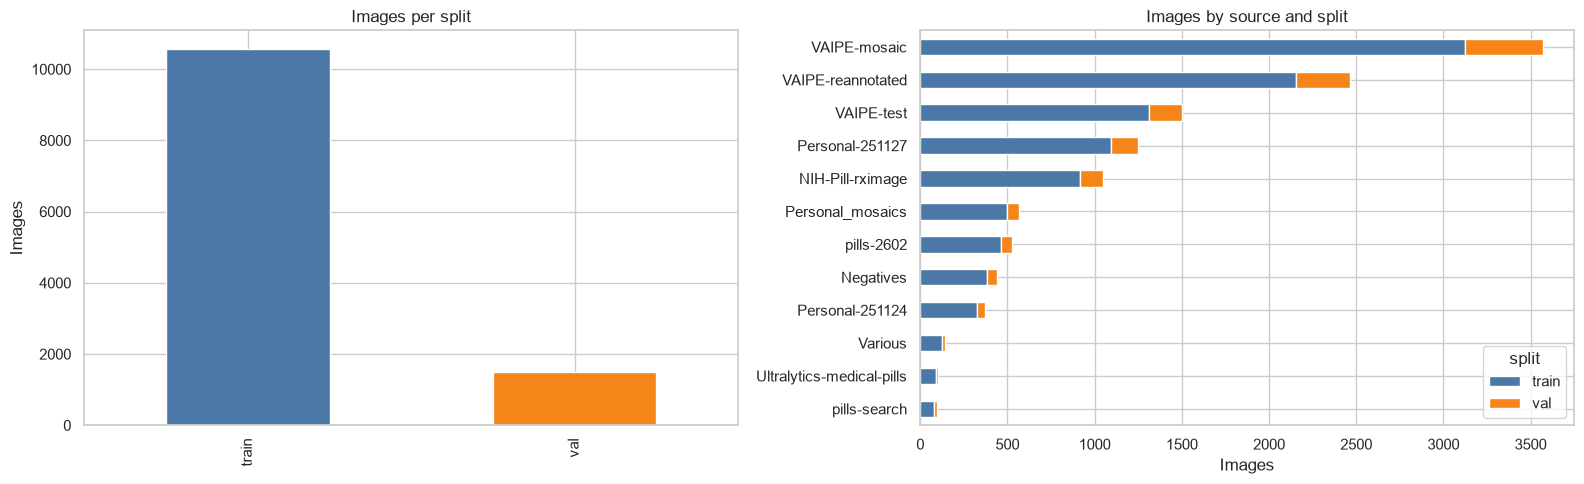

In [4]:
split_counts = images_df.groupby('split').size().rename('images').to_frame()
split_counts['percent'] = 100 * split_counts['images'] / len(images_df)
display(split_counts.round(2))

source_split = pd.crosstab(images_df['source'], images_df['split']).reindex(columns=SPLITS, fill_value=0)
source_split['total'] = source_split.sum(axis=1)
source_split = source_split.sort_values('total', ascending=False)
display(source_split)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
split_counts['images'].plot.bar(ax=axes[0], color=['#4C78A8', '#F58518', '#54A24B'][:len(split_counts)])
axes[0].set(title='Images per split', xlabel='', ylabel='Images')
source_split[SPLITS].plot.barh(stacked=True, ax=axes[1], color=['#4C78A8', '#F58518', '#54A24B'][:len(SPLITS)])
axes[1].set(title='Images by source and split', xlabel='Images', ylabel='')
axes[1].invert_yaxis()
plt.tight_layout();


## 3) Parse และ audit YOLO annotations

YOLO detection row ต้องมี `class_id x_center y_center width height` และพิกัด normalized ควรอยู่ในช่วง 0–1 รวมถึงขอบกล่องไม่ควรล้ำออกจากภาพ


In [5]:
annotation_rows, annotation_errors = [], []
empty_label_rows = []

for img in images_df.itertuples(index=False):
    label_path = img.label_path
    if label_path is None:
        continue
    text = label_path.read_text(encoding='utf-8').strip()
    if not text:
        empty_label_rows.append({'split': img.split, 'source': img.source, 'stem': img.stem})
        continue
    for line_no, line in enumerate(text.splitlines(), start=1):
        parts = line.split()
        if len(parts) != 5:
            annotation_errors.append({'path': label_path, 'line': line_no, 'error': 'expected 5 columns', 'raw': line})
            continue
        try:
            class_id, x, y, w, h = map(float, parts)
        except ValueError:
            annotation_errors.append({'path': label_path, 'line': line_no, 'error': 'non-numeric value', 'raw': line})
            continue
        x1, y1, x2, y2 = x - w / 2, y - h / 2, x + w / 2, y + h / 2
        annotation_rows.append({
            'split': img.split, 'source': img.source, 'stem': img.stem,
            'image_path': img.image_path, 'label_path': label_path, 'class_id': class_id,
            'x': x, 'y': y, 'w': w, 'h': h, 'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
            'area': w * h, 'box_aspect_ratio': w / h if h > 0 else np.nan,
            'valid_class': class_id.is_integer() and 0 <= class_id < len(config['names']),
            'valid_normalized': 0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1,
            'inside_image': x1 >= 0 and y1 >= 0 and x2 <= 1 and y2 <= 1,
        })

ann_df = pd.DataFrame(annotation_rows)
empty_df = pd.DataFrame(empty_label_rows)
objects_per_image = ann_df.groupby(['split', 'stem']).size().rename('objects').reset_index()
images_df = images_df.merge(objects_per_image, on=['split', 'stem'], how='left')
images_df['objects'] = images_df['objects'].fillna(0).astype(int)

audit = pd.DataFrame({
    'metric': ['boxes', 'empty label images', 'malformed rows', 'invalid class', 'invalid normalized values', 'boxes outside image'],
    'count': [len(ann_df), len(empty_df), len(annotation_errors), (~ann_df.valid_class).sum(),
              (~ann_df.valid_normalized).sum(), (~ann_df.inside_image).sum()]
})
display(audit)
display(pd.crosstab(empty_df['source'], empty_df['split'], margins=True) if len(empty_df) else 'No empty labels')

outside = ann_df.loc[~ann_df.inside_image].copy()
if len(outside):
    print(f'พบ {len(outside):,} boxes ที่ล้ำขอบภาพ')
    display(pd.crosstab(outside['source'], outside['split'], margins=True))
    display(outside[['split', 'source', 'stem', 'x1', 'y1', 'x2', 'y2']].head(20))


,metric,count
0,boxes,144111
1,empty label images,456
2,malformed rows,0
3,invalid class,0
4,invalid normalized values,0
5,boxes outside image,220


split,train,val,All
source,,,
Negatives,385,54,439
Personal-251127,15,2,17
All,400,56,456


พบ 220 boxes ที่ล้ำขอบภาพ


split,train,val,All
source,,,
NIH-Pill-rximage,3,1,4
Personal-251124,1,0,1
Personal_mosaics,4,1,5
Ultralytics-medical-pills,8,2,10
VAIPE-mosaic,5,0,5
VAIPE-test,1,0,1
pills-2602,125,17,142
pills-search,48,4,52
All,195,25,220


,split,source,stem,x1,y1,x2,y2
1252,train,NIH-Pill-rximage,NIH-Pill-rximage_A_0012,1.597480e-01,-5.000000e-07,0.209630,0.058513
10162,train,NIH-Pill-rximage,NIH-Pill-rximage_m_0158,6.819195e-01,4.130550e-02,1.000001,0.159441
14195,train,NIH-Pill-rximage,NIH-Pill-rximage_m_0414,6.807755e-01,3.781290e-01,1.000001,0.492215
25584,train,Personal-251124,Personal-251124_IMG_3549,2.842090e-01,-5.000000e-07,0.652877,0.220946
51141,train,Personal_mosaics,Personal_mosaics_pm3_165_166_167_168,-5.000000e-07,6.705925e-01,0.037377,0.714731
51335,train,Personal_mosaics,Personal_mosaics_pm3_177_178_179_180,7.439545e-01,9.574875e-01,0.793542,1.000000
64658,train,Personal_mosaics,Personal_mosaics_pm4_253_254_255_256,2.836800e-01,-5.000000e-07,0.327040,0.060318
71888,train,Personal_mosaics,Personal_mosaics_pm4_653_654_655_656,-5.000000e-07,6.912060e-01,0.032698,0.732582
74276,train,pills-2602,pills-2602_11_5184469615_ddc9f03968_c,3.156790e-01,-5.000000e-07,0.518035,0.213440
74541,train,pills-2602,pills-2602_11_google_0017,9.424775e-01,2.123855e-01,1.000001,0.317407


,images,empty_images,objects,mean_objects,median_objects,p95_objects,max_objects
split,,,,,,,
train,10559,400,126710,12.00,6.0,46.00,433
val,1508,56,17401,11.54,6.0,39.65,202


split                          train          val
w                count  126710.00000  17401.00000
                 mean        0.08936      0.09105
                 std         0.05818      0.05776
                 min         0.00236      0.00843
                 1%          0.02341      0.02509
                 5%          0.03005      0.03111
                 25%         0.04794      0.04954
                 50%         0.07085      0.07284
                 75%         0.11531      0.11704
                 95%         0.20483      0.20583
                 99%         0.30835      0.30809
                 max         0.88872      0.55524
h                count  126710.00000  17401.00000
                 mean        0.09597      0.09732
                 std         0.06227      0.06246
                 min         0.00210      0.01040
                 1%          0.02362      0.02511
                 5%          0.03024      0.03131
                 25%         0.04845      0.04942
                 50%         0.08036      0.08242
                 75%         0.12676      0.12815
                 95%         0.21829      0.21942
                 99%         0.31062      0.30772
                 max         0.74257      0.85573
area             count  126710.00000  17401.00000
                 mean        0.01058      0.01085
                 std         0.01226      0.01233
                 min         0.00000      0.00014
                 1%          0.00063      0.00069
                 5%          0.00093      0.00099
                 25%         0.00254      0.00275
                 50%         0.00568      0.00591
                 75%         0.01548      0.01597
                 95%         0.03237      0.03328
                 99%         0.04791      0.04843
                 max         0.42587      0.28319
box_aspect_ratio count  126710.00000  17401.00000
                 mean        1.03769      1.04243
                 std         0.49367      0.48819
                 min         0.06641      0.09919
                 1%          0.31233      0.31390
                 5%          0.41105      0.41736
                 25%         0.71603      0.71718
                 50%         0.99450      0.99485
                 75%         1.11970      1.12196
                 95%         2.06743      2.08461
                 99%         2.71165      2.69470
                 max        15.05682      6.73940

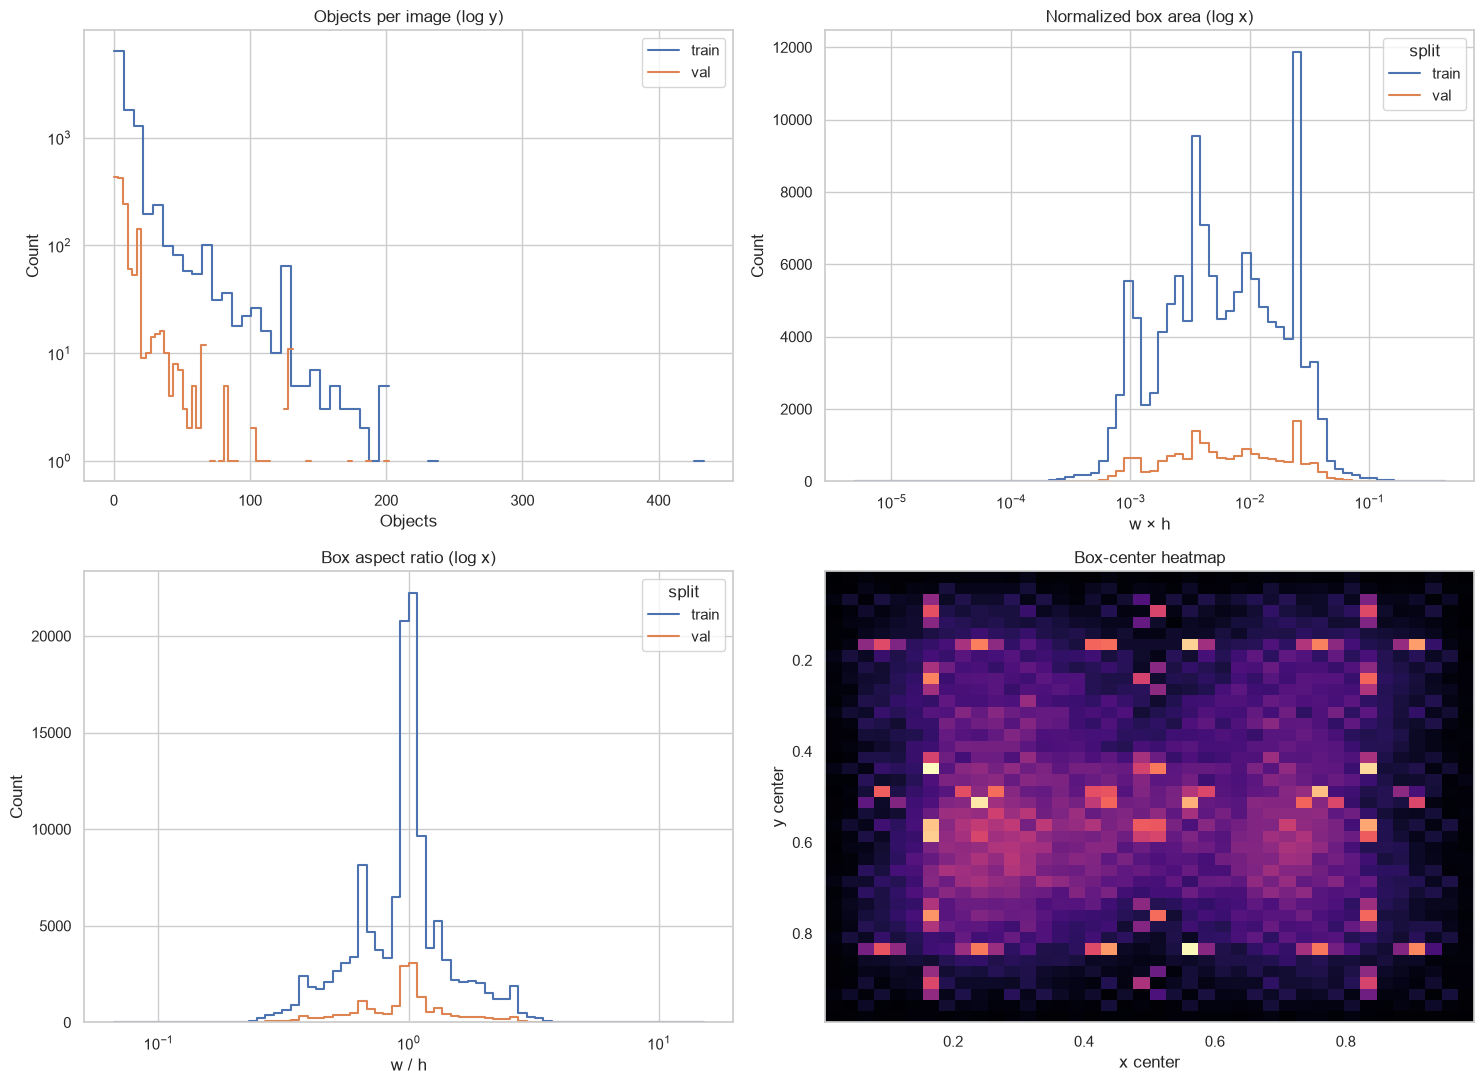

In [6]:
summary = images_df.groupby('split').agg(
    images=('stem', 'size'), empty_images=('objects', lambda s: (s == 0).sum()),
    objects=('objects', 'sum'), mean_objects=('objects', 'mean'),
    median_objects=('objects', 'median'), p95_objects=('objects', lambda s: s.quantile(.95)),
    max_objects=('objects', 'max'),
)
display(summary.round(2))
display(ann_df.groupby('split')[['w', 'h', 'area', 'box_aspect_ratio']].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T.round(5))

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for split in SPLITS:
    sns.histplot(images_df.loc[images_df.split == split, 'objects'], bins=60, element='step', fill=False,
                 log_scale=(False, True), label=split, ax=axes[0, 0])
axes[0, 0].set(title='Objects per image (log y)', xlabel='Objects'); axes[0, 0].legend()
sns.histplot(data=ann_df, x='area', hue='split', bins=70, log_scale=True, element='step', fill=False, ax=axes[0, 1])
axes[0, 1].set(title='Normalized box area (log x)', xlabel='w × h')
sns.histplot(data=ann_df, x='box_aspect_ratio', hue='split', bins=70, log_scale=True, element='step', fill=False, ax=axes[1, 0])
axes[1, 0].set(title='Box aspect ratio (log x)', xlabel='w / h')
axes[1, 1].hist2d(ann_df['x'], ann_df['y'], bins=40, cmap='magma')
axes[1, 1].invert_yaxis(); axes[1, 1].set(title='Box-center heatmap', xlabel='x center', ylabel='y center')
plt.tight_layout();


## 4) Resolution, aspect ratio และ domain/density balance


,split,resolution,images
308,train,960×640,3125
104,train,480×640,2577
10,train,1024×1024,1110
286,train,900×900,854
194,train,640×480,739
232,train,720×720,736
253,train,768×1024,377
33,train,1024×768,121
24,train,1024×576,95
100,train,479×640,90


,source,split,images,objects,empty_images,mean_objects,median_mp
0,NIH-Pill-rximage,train,914,23032,0,25.20,0.81
1,NIH-Pill-rximage,val,131,3346,0,25.54,0.81
2,Negatives,train,385,0,385,0.00,0.52
3,Negatives,val,54,0,54,0.00,0.52
4,Personal-251124,train,324,2611,0,8.06,0.79
5,Personal-251124,val,46,326,0,7.09,0.79
6,Personal-251127,train,1093,19043,15,17.42,1.05
7,Personal-251127,val,157,2711,2,17.27,1.05
8,Personal_mosaics,train,497,29218,0,58.79,1.05
9,Personal_mosaics,val,71,3928,0,55.32,1.05


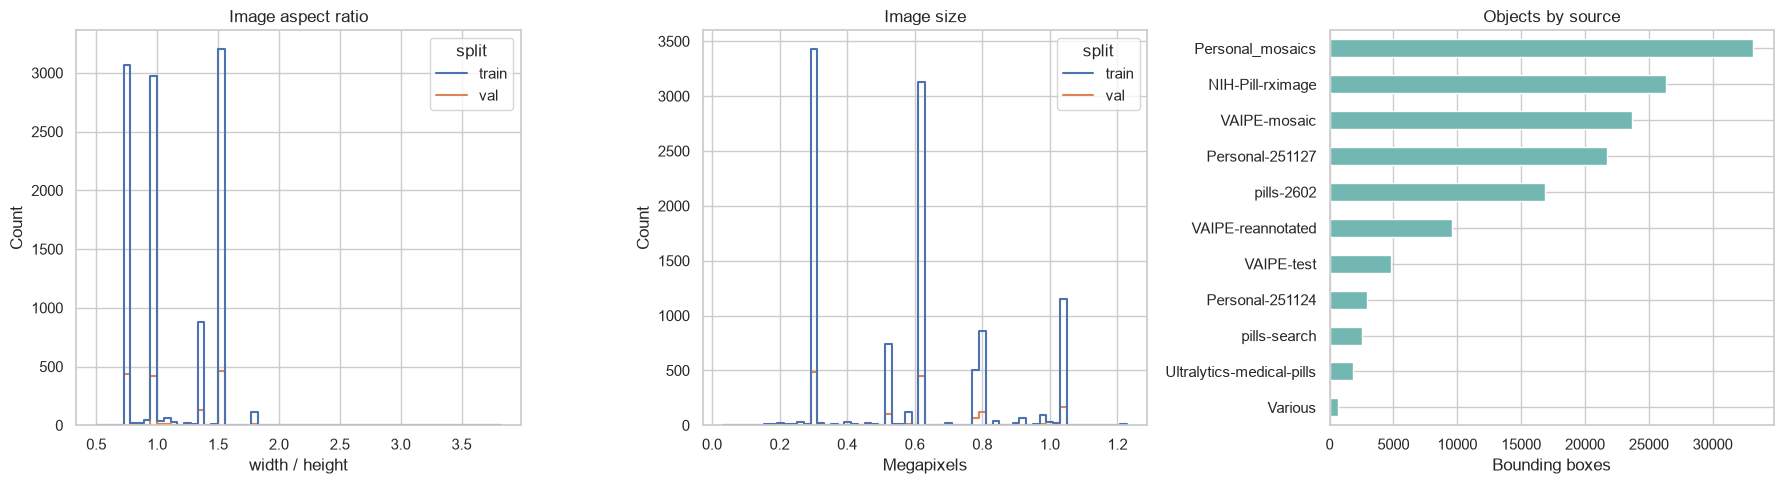

In [7]:
resolution_table = (images_df.assign(resolution=images_df.width.astype(str) + '×' + images_df.height.astype(str))
                    .groupby(['split', 'resolution']).size().rename('images').reset_index()
                    .sort_values(['split', 'images'], ascending=[True, False]))
display(resolution_table.groupby('split').head(12))

source_stats = images_df.groupby(['source', 'split']).agg(
    images=('stem', 'size'), objects=('objects', 'sum'), empty_images=('objects', lambda s: (s == 0).sum()),
    mean_objects=('objects', 'mean'), median_mp=('megapixels', 'median')
).reset_index()
display(source_stats.sort_values(['source', 'split']).round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=images_df, x='aspect_ratio', hue='split', bins=60, element='step', fill=False, ax=axes[0])
axes[0].set(title='Image aspect ratio', xlabel='width / height')
sns.histplot(data=images_df, x='megapixels', hue='split', bins=60, element='step', fill=False, ax=axes[1])
axes[1].set(title='Image size', xlabel='Megapixels')
source_object_totals = ann_df.groupby('source').size().sort_values()
source_object_totals.plot.barh(ax=axes[2], color='#72B7B2')
axes[2].set(title='Objects by source', xlabel='Bounding boxes', ylabel='')
plt.tight_layout();


## 5) แสดงภาพและ bounding boxes

ใช้ตรวจ annotation ด้วยสายตา ทั้งภาพทั่วไป, negative และภาพที่มี object หนาแน่น


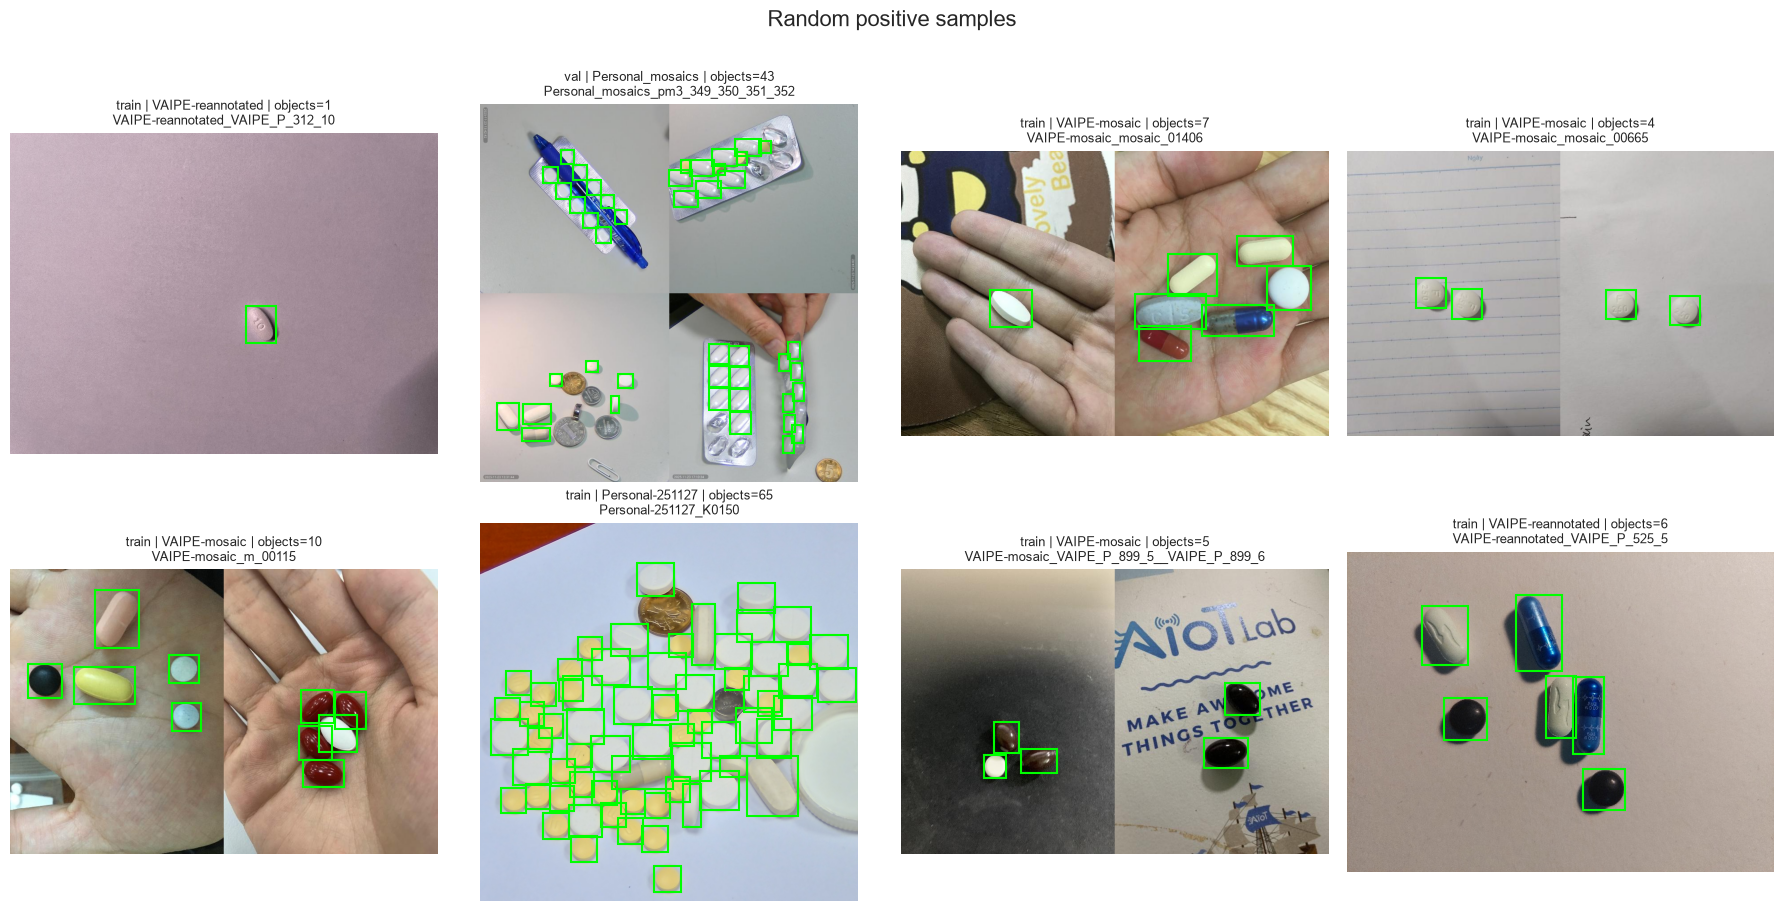

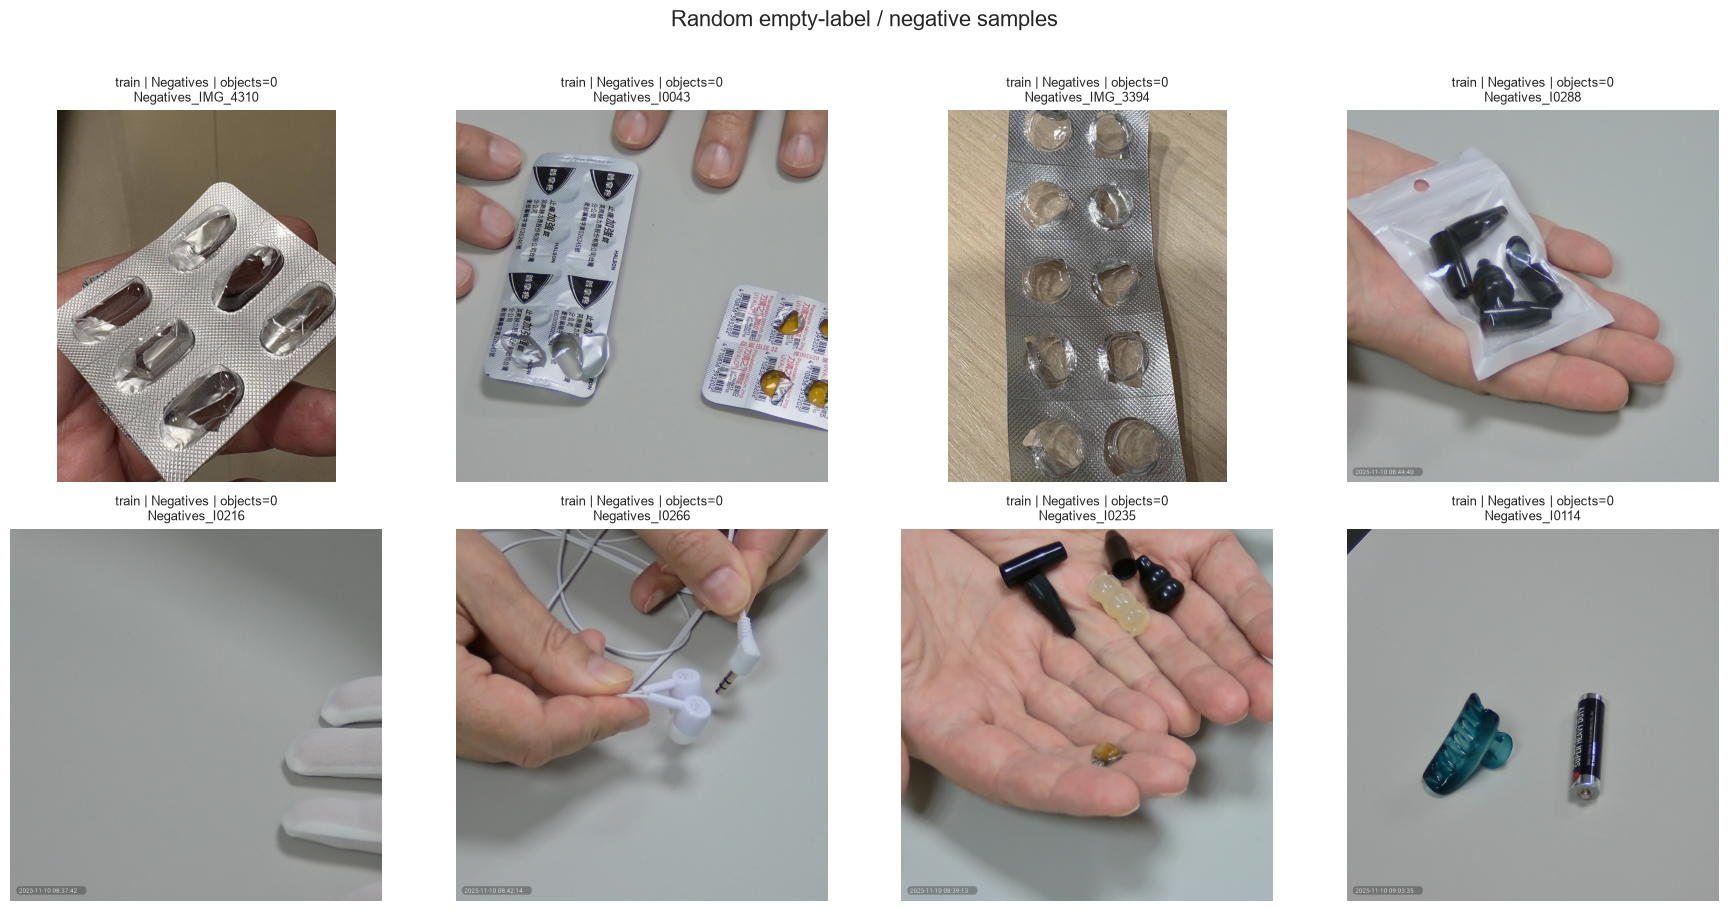

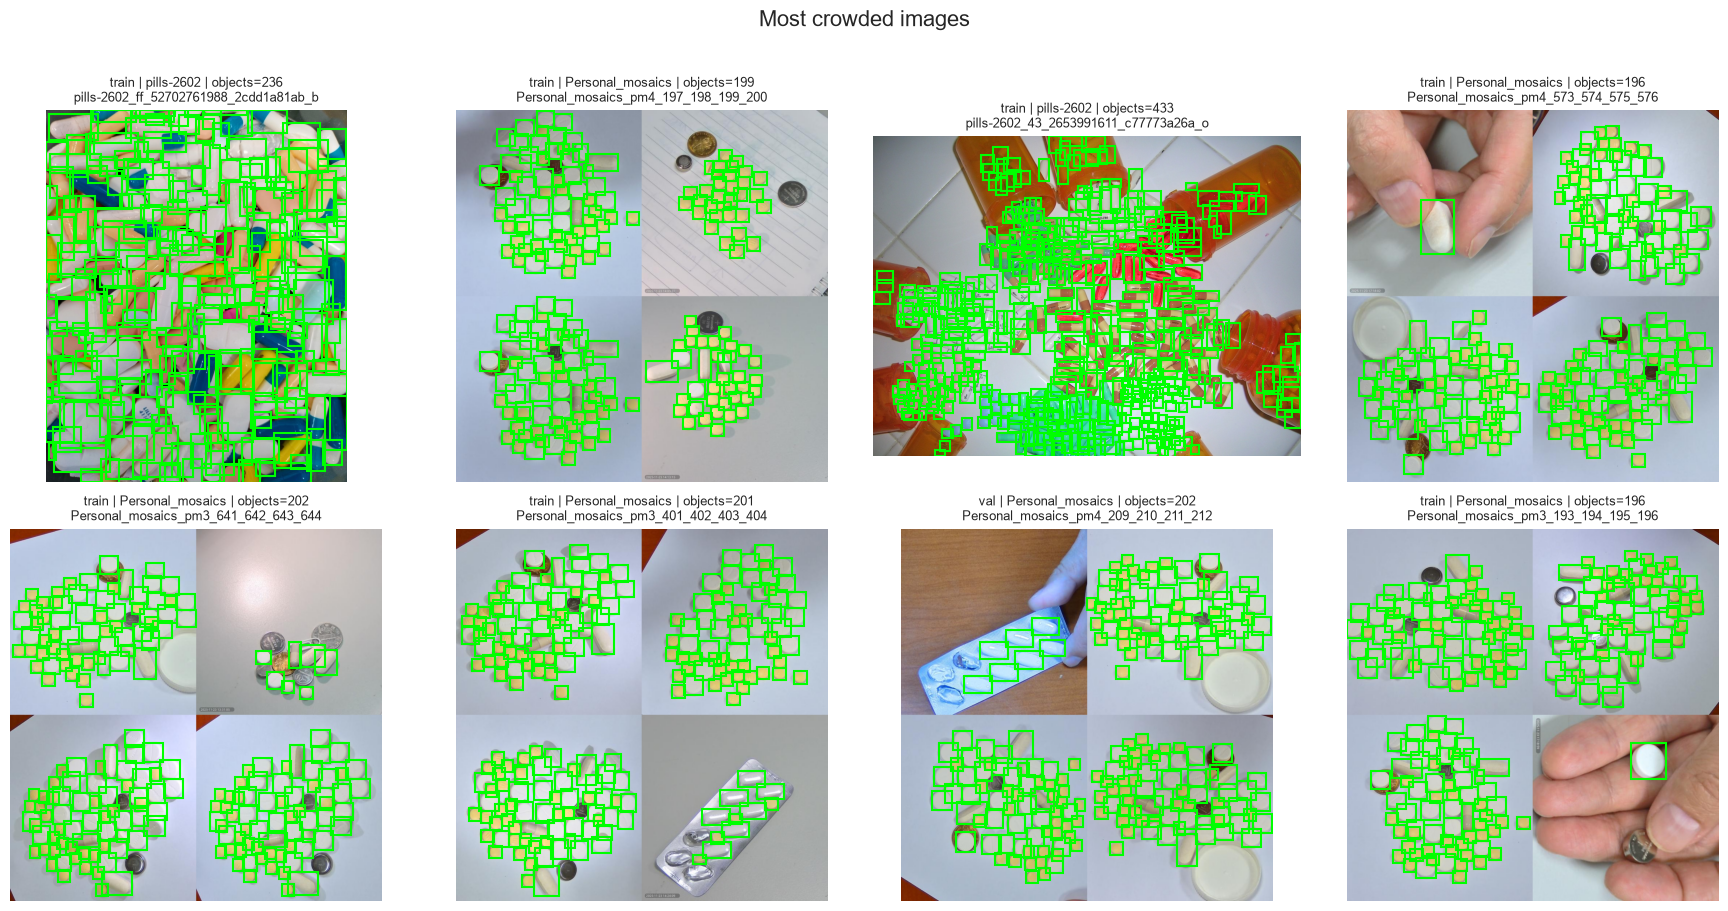

In [8]:
def show_samples(sample_df, title, n=8, seed=SEED):
    if sample_df.empty:
        print(f'No samples: {title}')
        return
    chosen = sample_df.sample(min(n, len(sample_df)), random_state=seed)
    cols = 4
    rows = math.ceil(len(chosen) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4.5 * rows), squeeze=False)
    for ax in axes.ravel(): ax.axis('off')
    for ax, row in zip(axes.ravel(), chosen.itertuples(index=False)):
        with Image.open(row.image_path) as im:
            image = ImageOps.exif_transpose(im).convert('RGB')
        ax.imshow(image)
        boxes = ann_df[(ann_df.split == row.split) & (ann_df.stem == row.stem)]
        for b in boxes.itertuples(index=False):
            rect = patches.Rectangle((b.x1 * image.width, b.y1 * image.height), b.w * image.width, b.h * image.height,
                                     linewidth=1.5, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
        ax.set_title(f'{row.split} | {row.source} | objects={row.objects}\n{row.stem}', fontsize=9)
        ax.axis('off')
    fig.suptitle(title, fontsize=16, y=1.01)
    plt.tight_layout()

show_samples(images_df[images_df.objects > 0], 'Random positive samples')
show_samples(images_df[images_df.objects == 0], 'Random empty-label / negative samples')
show_samples(images_df.nlargest(8, 'objects'), 'Most crowded images', n=8)


## 6) Exact duplicates และ cross-split leakage

คำนวณ SHA-256 จากเนื้อไฟล์จริงทั้งหมด (~1.37 GB) เพื่อหา exact duplicate เซลล์นี้อาจใช้เวลา 20–60 วินาทีตาม disk


In [9]:
def sha256_file(path, chunk_size=2**20):
    digest = hashlib.sha256()
    with path.open('rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()

hash_df = images_df[['split', 'source', 'stem', 'image_path']].copy()
hash_df['sha256'] = hash_df['image_path'].map(sha256_file)
duplicate_df = hash_df[hash_df.duplicated('sha256', keep=False)].sort_values('sha256')
cross_hashes = (duplicate_df.groupby('sha256')['split'].nunique().loc[lambda s: s > 1].index)
cross_split_duplicates = duplicate_df[duplicate_df.sha256.isin(cross_hashes)]

print(f'Duplicate groups : {duplicate_df.sha256.nunique():,}')
print(f'Duplicate files  : {len(duplicate_df):,}')
print(f'Cross-split groups: {len(cross_hashes):,}')
display(cross_split_duplicates)

# ชื่อไฟล์ที่ถูกยืนยันว่าซ้ำข้าม split ใน snapshot ปัจจุบัน
# train/Various_drugs-hand_44527-267.jpg <-> val/Various_medicine(44).jpg
# train/Various_medicine(62).jpg <-> val/Various_medicine-pills-capsules-hand_20693-98.jpg


Duplicate groups : 4
Duplicate files  : 8
Cross-split groups: 2


,split,source,stem,image_path,sha256
10502,train,Various,Various_medicine(62),C:\Learn\steel_surface_detection\pill-dataset\...,905579c0c9590fc9ebd91f79c0b783ed0db853a67352d9...
12063,val,Various,Various_medicine-pills-capsules-hand_20693-98,C:\Learn\steel_surface_detection\pill-dataset\...,905579c0c9590fc9ebd91f79c0b783ed0db853a67352d9...
10444,train,Various,Various_drugs-hand_44527-267,C:\Learn\steel_surface_detection\pill-dataset\...,c2af2a1b7ee97f8810f366107e95cdcdc7f6a60c0ec040...
12056,val,Various,Various_medicine(44),C:\Learn\steel_surface_detection\pill-dataset\...,c2af2a1b7ee97f8810f366107e95cdcdc7f6a60c0ec040...


## 7) ข้อเสนอแนะก่อนเทรน

1. **แก้ leakage ก่อนวัดผล**: ย้าย/ลบ exact duplicates ไม่ให้ข้าม split และสร้าง split ใหม่แบบ group-aware ตามภาพต้นฉบับ, session, video หรือ pill pack โดยเฉพาะ source ที่สร้างภาพต่อเนื่อง/mosaic
2. **สร้าง test set ที่ไม่เคยเห็น**: แนะนำ train/val/test เช่น 75/15/10 โดย group ตามต้นฉบับ ไม่ใช่สุ่มรายภาพ และรักษาสัดส่วน source/negative
3. **แก้ annotation ล้ำขอบ 220 กล่อง**: clip `x1,y1,x2,y2` ให้อยู่ใน `[0,1]` แล้วแปลงกลับ YOLO; ตรวจด้วยภาพก่อน overwrite เสมอ
4. **ยืนยัน empty labels 17 ภาพจาก Personal-251127**: ถ้ามี pill ที่ไม่ได้ annotate จะกลายเป็น false-negative supervision
5. **รองรับ small objects**: เริ่มทดลอง `imgsz=960` หรือ `1024`; หาก GPU ไม่พอให้ลด batch, ใช้ multi-scale หรือ tile/crop โดยคง pill ทั้งเม็ดและตรวจ annotation หลัง augmentation
6. **จัดการความหนาแน่นที่ต่างกันมาก**: มีตั้งแต่ 0 ถึง 433 objects/image ควรดู metric แยกตาม source และช่วงจำนวนวัตถุ (negative / sparse / crowded) ไม่ดูเฉพาะ mAP รวม
7. **ใช้ metric ที่เหมาะสม**: รายงาน mAP50-95, precision, recall และ false positives บน negative images รวมทั้ง AP แยก small/medium/large หาก pipeline รองรับ
8. **ตรวจ domain balance**: dataset มีเพียง class เดียว จึงไม่มี class imbalance แต่มี source/domain imbalance และ object-density imbalance ควรใช้ source-aware sampling หรือวิเคราะห์ผลแยก source
9. **แก้ YAML ให้ชัดเจน**: หาก YAML อยู่ที่ `pill-dataset/images/data.yaml` ให้ใช้ `path: ..`, `train: images/train`, `val: images/val` หรือสร้าง YAML ใหม่ที่ dataset root

### Baseline ที่แนะนำ

เริ่มจาก pretrained YOLO รุ่นเล็กที่ `imgsz=960`, ใช้ batch สูงสุดที่ GPU รับได้, early stopping และเก็บผลแยก source จากนั้นค่อยเปรียบเทียบ `imgsz=640` กับ `960/1024` เพื่อวัดผลต่อ small objects และเวลา inference อย่างเป็นระบบ
